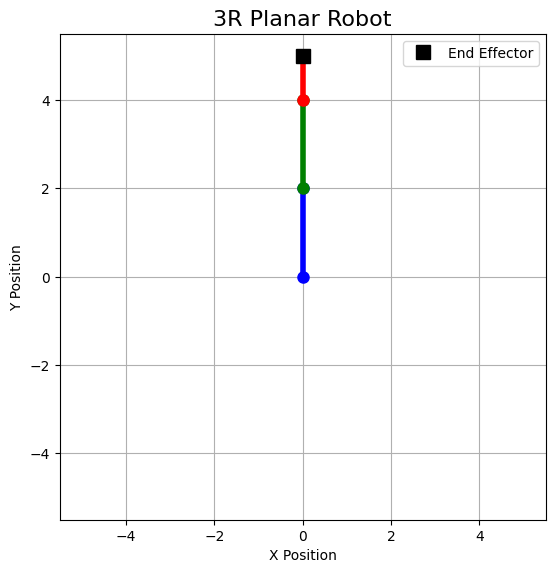

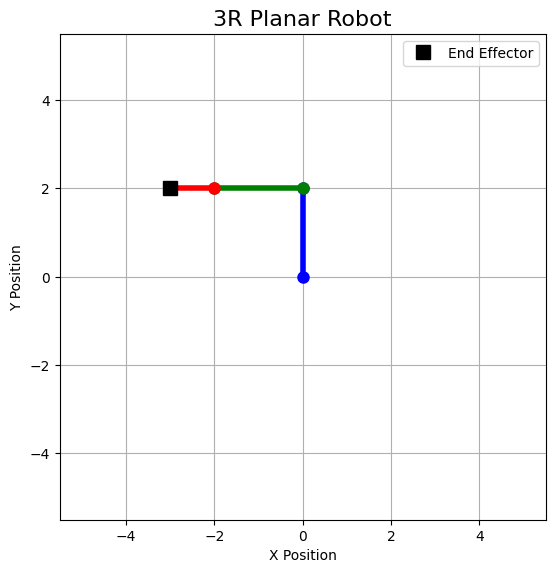

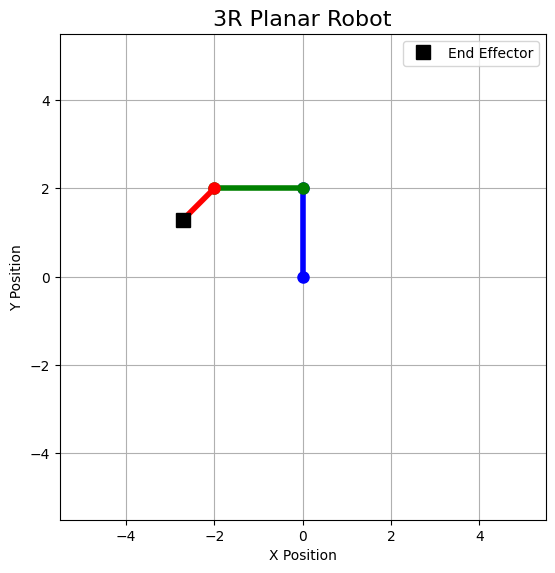

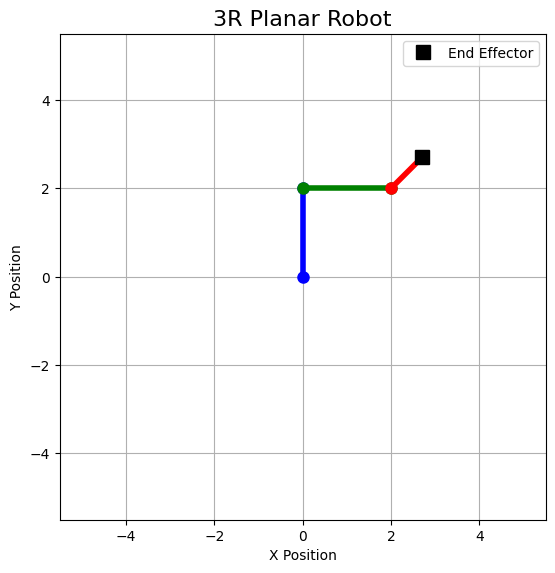

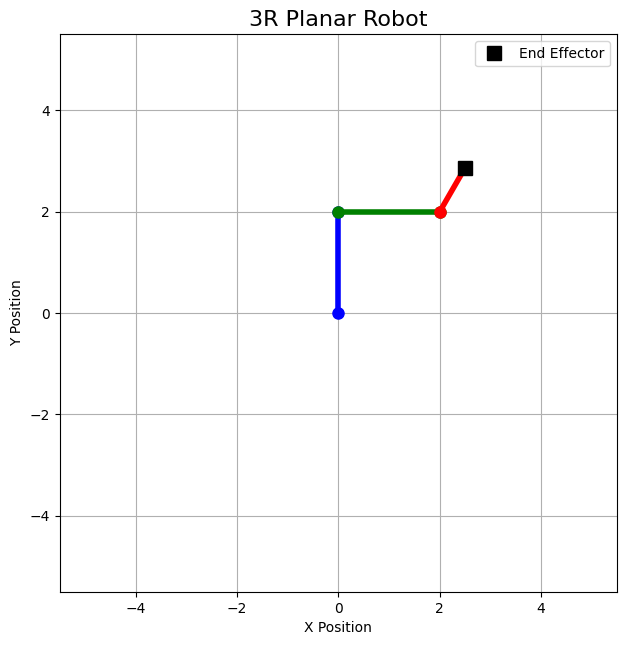

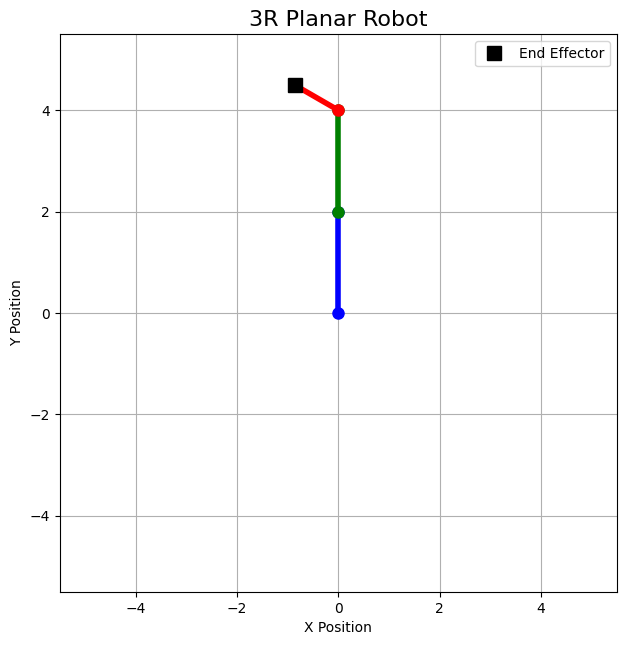

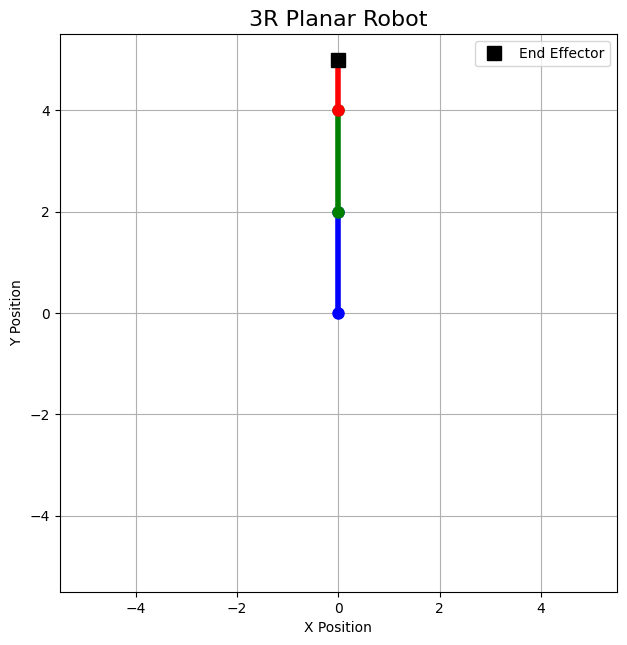

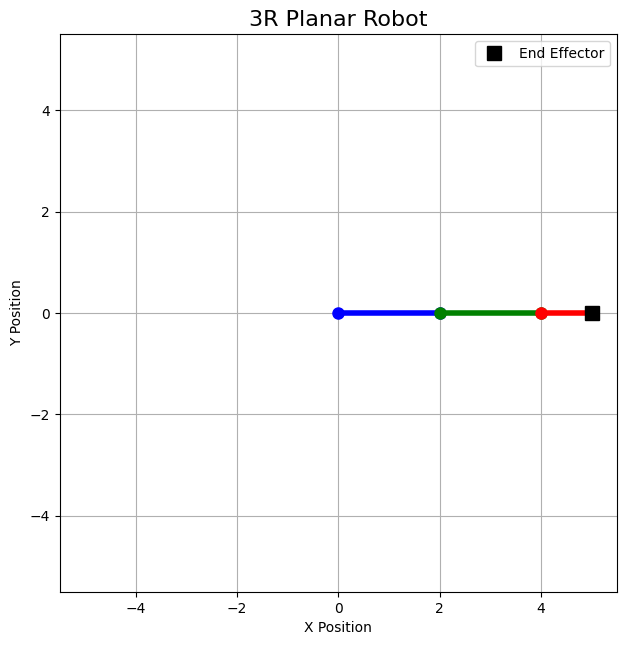

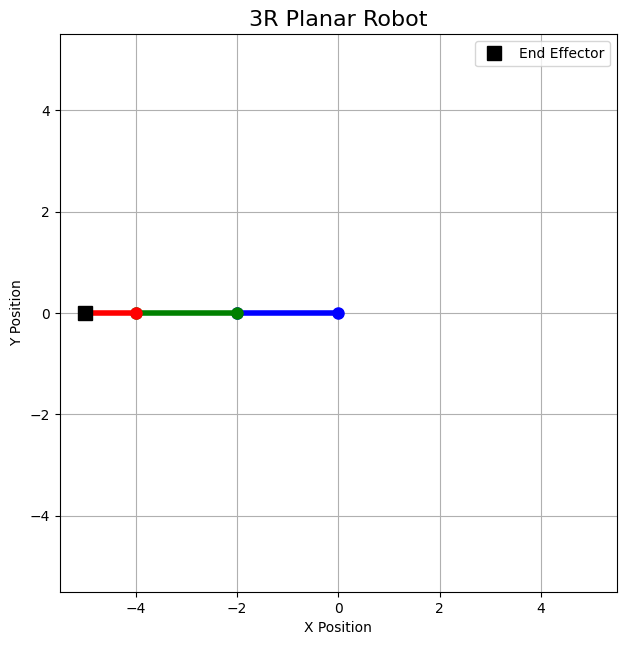

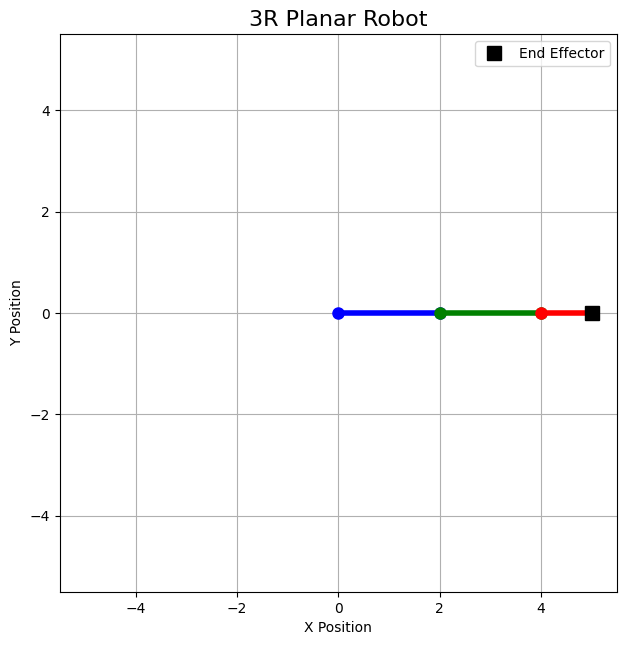

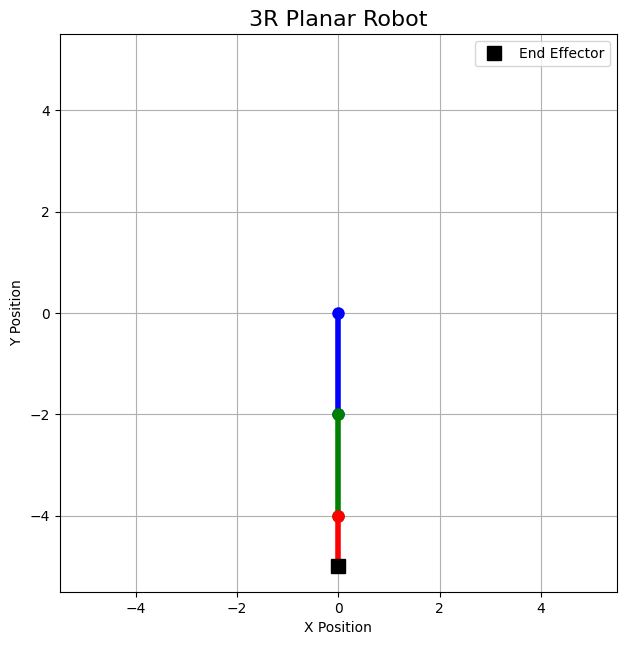

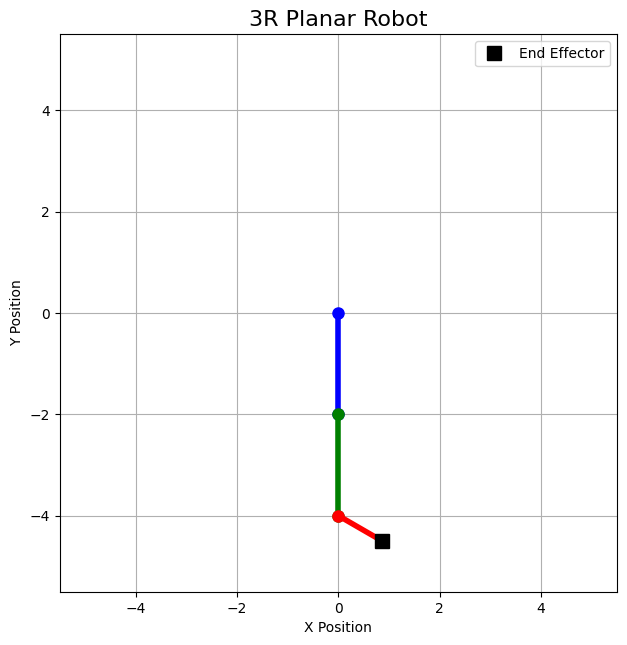

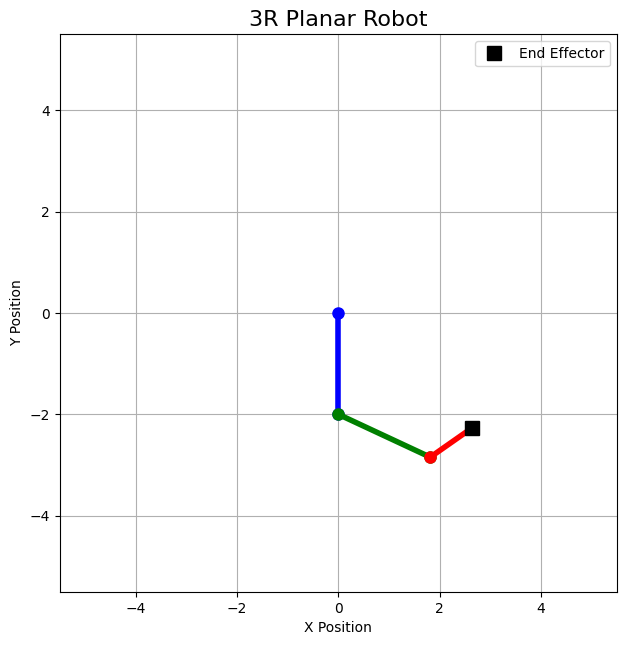

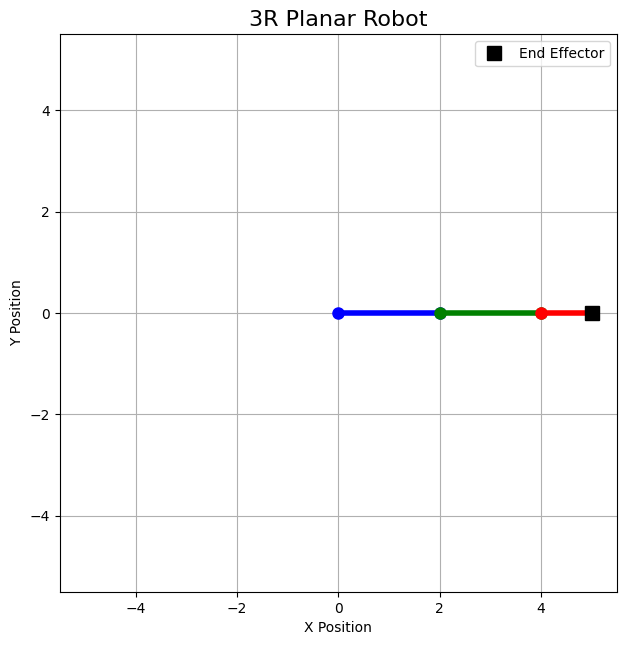

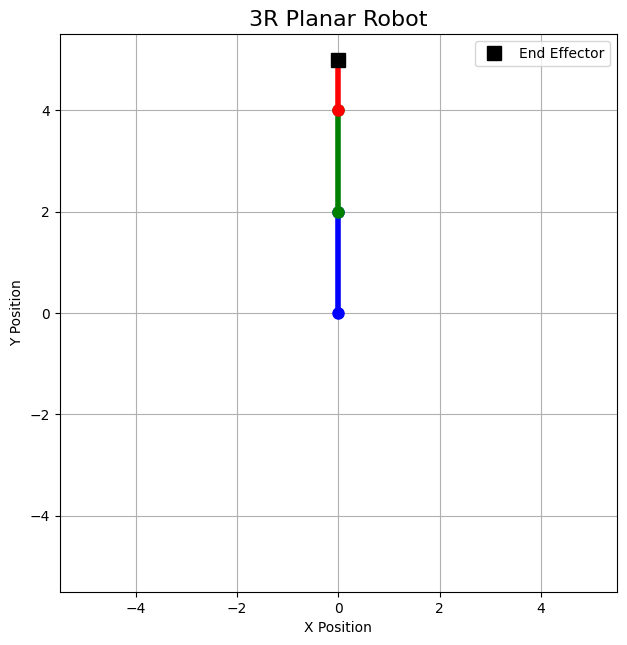

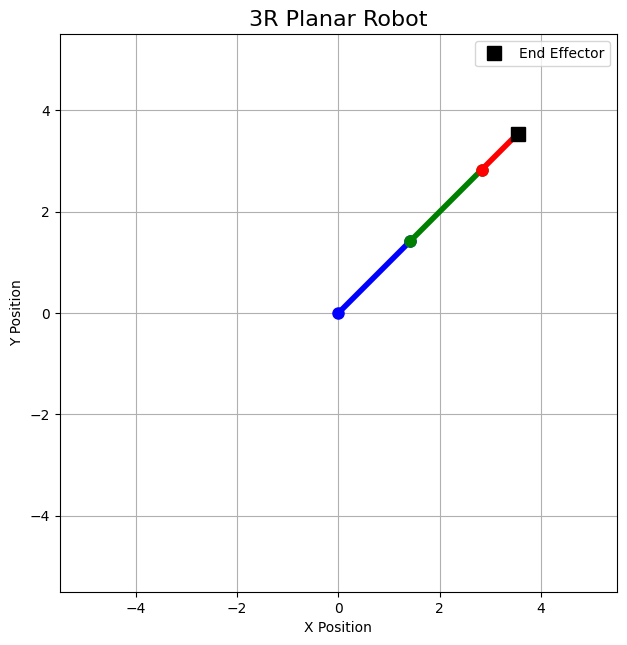

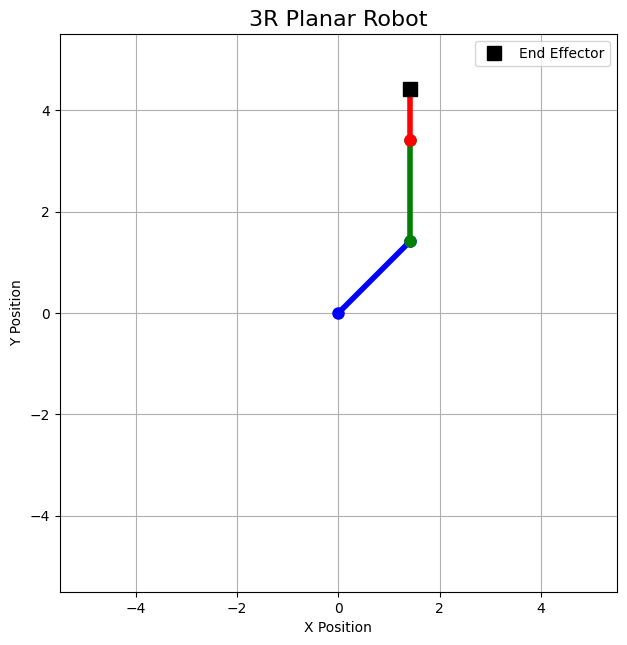

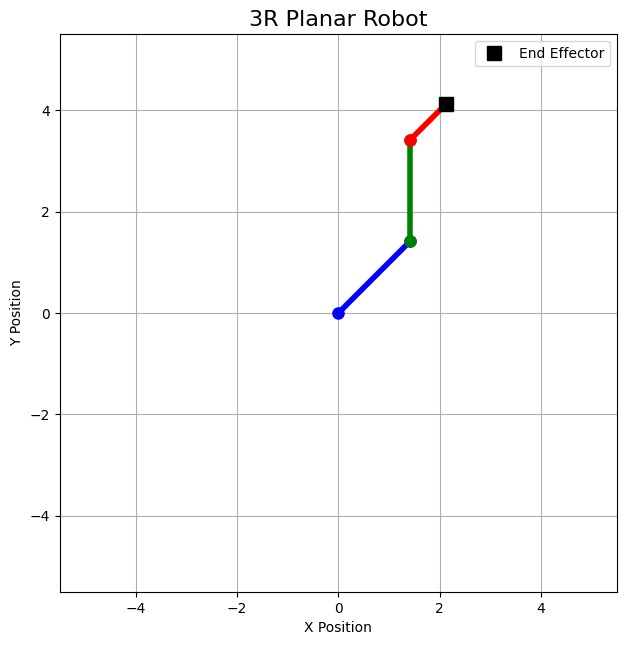

In [12]:
import numpy as np
import tkinter as tk
from tkinter import ttk
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg

# ==========================================
# Robot Parameters
# ==========================================
L1 = 2
L2 = 2
L3 = 1

# ==========================================
# Forward Kinematics Function
# ==========================================
def compute_fk():

    try:
        theta1_deg = float(entry_theta1.get())
        theta2_deg = float(entry_theta2.get())
        theta3_deg = float(entry_theta3.get())

        theta1 = np.radians(theta1_deg)
        theta2 = np.radians(theta2_deg)
        theta3 = np.radians(theta3_deg)

        # Joint Coordinates
        x0, y0 = 0, 0

        x1 = L1 * np.cos(theta1)
        y1 = L1 * np.sin(theta1)

        x2 = x1 + L2 * np.cos(theta1 + theta2)
        y2 = y1 + L2 * np.sin(theta1 + theta2)

        x3 = x2 + L3 * np.cos(theta1 + theta2 + theta3)
        y3 = y2 + L3 * np.sin(theta1 + theta2 + theta3)

        phi = theta1_deg + theta2_deg + theta3_deg

        # Display Results
        label_x.config(text=f"X = {x3:.3f}")
        label_y.config(text=f"Y = {y3:.3f}")
        label_phi.config(text=f"Orientation = {phi:.3f}°")

        # Remove Previous Plot
        for widget in plot_frame.winfo_children():
            widget.destroy()

        # ==========================================
        # Plot Robot
        # ==========================================
        fig, ax = plt.subplots(figsize=(7, 7))

        ax.plot([x0, x1], [y0, y1],
                'bo-', linewidth=4, markersize=8)

        ax.plot([x1, x2], [y1, y2],
                'go-', linewidth=4, markersize=8)

        ax.plot([x2, x3], [y2, y3],
                'ro-', linewidth=4, markersize=8)

        ax.plot(x3, y3,
                'ks', markersize=10,
                label='End Effector')

        ax.set_title("3R Planar Robot", fontsize=16)

        ax.set_xlabel("X Position")
        ax.set_ylabel("Y Position")

        ax.grid(True)

        # Square Plot
        ax.set_aspect('equal', adjustable='box')

        reach = L1 + L2 + L3

        ax.set_xlim(-reach-0.5, reach+0.5)
        ax.set_ylim(-reach-0.5, reach+0.5)

        ax.legend()

        canvas = FigureCanvasTkAgg(fig, master=plot_frame)
        canvas.draw()
        canvas.get_tk_widget().pack(fill=tk.BOTH, expand=True)

    except ValueError:

        label_x.config(text="Invalid Input")
        label_y.config(text="")
        label_phi.config(text="")


# ==========================================
# Main Window
# ==========================================
root = tk.Tk()
root.title("3R Planar Robot Forward Kinematics")
root.geometry("1200x700")

# ==========================================
# Main Frame
# ==========================================
main_frame = ttk.Frame(root)
main_frame.pack(fill="both", expand=True)

# ==========================================
# LEFT PANEL
# ==========================================
left_frame = ttk.Frame(main_frame)
left_frame.pack(side="left",
                fill="y",
                padx=15,
                pady=15)

# ==========================================
# Input Frame
# ==========================================
input_frame = ttk.LabelFrame(
    left_frame,
    text="Joint Angles Input",
    padding=15
)
input_frame.pack(fill="x", pady=10)

ttk.Label(input_frame,
          text="θ1 (deg):",
          font=("Arial", 11)).grid(row=0,
                                   column=0,
                                   padx=5,
                                   pady=8)

entry_theta1 = ttk.Entry(input_frame, width=15)
entry_theta1.grid(row=0, column=1)

ttk.Label(input_frame,
          text="θ2 (deg):",
          font=("Arial", 11)).grid(row=1,
                                   column=0,
                                   padx=5,
                                   pady=8)

entry_theta2 = ttk.Entry(input_frame, width=15)
entry_theta2.grid(row=1, column=1)

ttk.Label(input_frame,
          text="θ3 (deg):",
          font=("Arial", 11)).grid(row=2,
                                   column=0,
                                   padx=5,
                                   pady=8)

entry_theta3 = ttk.Entry(input_frame, width=15)
entry_theta3.grid(row=2, column=1)

compute_button = ttk.Button(
    input_frame,
    text="Compute",
    command=compute_fk
)

compute_button.grid(row=3,
                    column=0,
                    columnspan=2,
                    pady=15)

# ==========================================
# Output Frame
# ==========================================
result_frame = ttk.LabelFrame(
    left_frame,
    text="End Effector Output",
    padding=15
)
result_frame.pack(fill="x", pady=10)

label_x = ttk.Label(result_frame,
                    text="X = ",
                    font=("Arial", 11))
label_x.pack(anchor="w", pady=5)

label_y = ttk.Label(result_frame,
                    text="Y = ",
                    font=("Arial", 11))
label_y.pack(anchor="w", pady=5)

label_phi = ttk.Label(result_frame,
                      text="Orientation = ",
                      font=("Arial", 11))
label_phi.pack(anchor="w", pady=5)

# ==========================================
# RIGHT PANEL (PLOT)
# ==========================================
plot_frame = ttk.LabelFrame(
    main_frame,
    text="Robot Configuration",
    padding=10
)

plot_frame.pack(side="right",
                fill="both",
                expand=True,
                padx=15,
                pady=15)

# ==========================================
# Run Application
# ==========================================
root.mainloop()